In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import importlib
import inspect
import torch
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# preprocessing

In [10]:
df_half_hour=pd.read_csv('daily_max_temp_SDL.csv')
df_half_hour.isna().sum()

temp_c    0
dtype: int64

In [11]:
daily_max_temp=df_half_hour
daily_max_temp

,temp_c
0,19.444444
1,20.555556
2,21.666667
3,22.222222
4,21.666667
...,...
5402,34.444444
5403,32.222222
5404,28.333333
5405,20.555556


In [12]:
percentile_90 = np.percentile(daily_max_temp['temp_c'], 90)
print(f"90th Percentile of max_temp_c: {percentile_90}")
daily_max_temp

90th Percentile of max_temp_c: 41.11111111111112


,temp_c
0,19.444444
1,20.555556
2,21.666667
3,22.222222
4,21.666667
...,...
5402,34.444444
5403,32.222222
5404,28.333333
5405,20.555556


# some functions needed

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.optimizers import Adam  # Import the Adam optimizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Normalize data
def normalize_data(data):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_data = scaler.fit_transform(data)
    return scaled_data, scaler

# Sequence creation for 7-day input and 3-day output
def create_sequences_7_3(data, input_seq_length=7, output_seq_length=3):
    sequences, labels = [], []
    for i in range(len(data) - input_seq_length - output_seq_length + 1):
        seq = data[i:i + input_seq_length]
        label = data[i + input_seq_length:i + input_seq_length + output_seq_length]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)


# Quantum lstm  seq7 predict 3

In [14]:
import torch
import torch.nn as nn
import pennylane as qml

class zzfeatuermapQLSTM(nn.Module):
    def __init__(self,
                 input_size,
                 hidden_size,
                 n_qubits=4,
                 n_qlayers=1,
                 batch_first=True,
                 return_sequences=False,
                 return_state=False,
                 backend="default.qubit"):
        super(zzfeatuermapQLSTM, self).__init__()
        self.n_inputs = input_size
        self.hidden_size = hidden_size
        self.concat_size = self.n_inputs + self.hidden_size
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers
        self.backend = backend

        self.batch_first = batch_first
        self.return_sequences = return_sequences
        self.return_state = return_state

        # Define wire names for devices
        self.wires_forget = [f"wire_forget_{i}" for i in range(self.n_qubits)]
        self.wires_input = [f"wire_input_{i}" for i in range(self.n_qubits)]
        self.wires_update = [f"wire_update_{i}" for i in range(self.n_qubits)]
        self.wires_output = [f"wire_output_{i}" for i in range(self.n_qubits)]

        self.dev_forget = qml.device(self.backend, wires=self.wires_forget)
        self.dev_input = qml.device(self.backend, wires=self.wires_input)
        self.dev_update = qml.device(self.backend, wires=self.wires_update)
        self.dev_output = qml.device(self.backend, wires=self.wires_output)

        # Define quantum circuits with IQPEmbedding
        def _circuit_forget(inputs, weights):
            qml.templates.IQPEmbedding(inputs, wires=self.wires_forget, n_repeats=1)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_forget)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_forget]

        def _circuit_input(inputs, weights):
            qml.templates.IQPEmbedding(inputs, wires=self.wires_input, n_repeats=1)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_input)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_input]

        def _circuit_update(inputs, weights):
            qml.templates.IQPEmbedding(inputs, wires=self.wires_update, n_repeats=1)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_update)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_update]

        def _circuit_output(inputs, weights):
            qml.templates.IQPEmbedding(inputs, wires=self.wires_output, n_repeats=1)
            qml.templates.BasicEntanglerLayers(weights, wires=self.wires_output)
            return [qml.expval(qml.PauliZ(wires=w)) for w in self.wires_output]

        self.qlayer_forget = qml.QNode(_circuit_forget, self.dev_forget, interface="torch")
        self.qlayer_input = qml.QNode(_circuit_input, self.dev_input, interface="torch")
        self.qlayer_update = qml.QNode(_circuit_update, self.dev_update, interface="torch")
        self.qlayer_output = qml.QNode(_circuit_output, self.dev_output, interface="torch")

        weight_shapes = {"weights": (n_qlayers, n_qubits)}
        print(f"weight_shapes = (n_qlayers, n_qubits) = ({n_qlayers}, {n_qubits})")

        self.clayer_in = torch.nn.Linear(self.concat_size, n_qubits)
        self.VQC = {
            'forget': qml.qnn.TorchLayer(self.qlayer_forget, weight_shapes),
            'input': qml.qnn.TorchLayer(self.qlayer_input, weight_shapes),
            'update': qml.qnn.TorchLayer(self.qlayer_update, weight_shapes),
            'output': qml.qnn.TorchLayer(self.qlayer_output, weight_shapes)
        }
        self.clayer_out = torch.nn.Linear(self.n_qubits, self.hidden_size)

    def forward(self, x, init_states=None):
        if self.batch_first:
            batch_size, seq_length, _ = x.size()
        else:
            seq_length, batch_size, _ = x.size()

        hidden_seq = []
        if init_states is None:
            h_t = torch.zeros(batch_size, self.hidden_size)
            c_t = torch.zeros(batch_size, self.hidden_size)
        else:
            h_t, c_t = init_states
            h_t = h_t[0]
            c_t = c_t[0]

        for t in range(seq_length):
            x_t = x[:, t, :]
            v_t = torch.cat((h_t, x_t), dim=1)
            y_t = self.clayer_in(v_t)

            f_t = torch.sigmoid(self.clayer_out(self.VQC['forget'](y_t)))
            i_t = torch.sigmoid(self.clayer_out(self.VQC['input'](y_t)))
            g_t = torch.tanh(self.clayer_out(self.VQC['update'](y_t)))
            o_t = torch.sigmoid(self.clayer_out(self.VQC['output'](y_t)))

            c_t = (f_t * c_t) + (i_t * g_t)
            h_t = o_t * torch.tanh(c_t)

            hidden_seq.append(h_t.unsqueeze(0))

        hidden_seq = torch.cat(hidden_seq, dim=0).transpose(0, 1).contiguous()
        return hidden_seq, (h_t, c_t)
class LSTMRegressor_7_3(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=0, n_qlayers=1, backend='default.qubit'):
        super(LSTMRegressor_7_3, self).__init__()
        self.hidden_dim = hidden_dim
        if n_qubits > 0:
            print(f"Using Quantum LSTM on backend {backend}")
            self.lstm = zzfeatuermapQLSTM(input_dim, hidden_dim, n_qubits=n_qubits, n_qlayers=n_qlayers, backend=backend)
        else:
            print("Using Classical LSTM")
            self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 3)  # Output 3 values for 3-day prediction

    def forward(self, x):
        lstm_out, _ = self.lstm(x.view(x.shape[0], x.shape[1], -1))
        output = self.fc(lstm_out[:, -1])  # Predict 3 days from last hidden state
        return output


In [15]:
data = daily_max_temp['temp_c'].values.reshape(-1, 1)

data_normalized, scaler = normalize_data(data)

# Initialize variables
input_seq_length = 7
output_seq_length = 3

# Create sequences
X_7_3, y_7_3 = create_sequences_7_3(data_normalized, input_seq_length, output_seq_length)
print(f"Number of sequences: {len(X_7_3)}")  # Should be 1 for 10 values

# For small dataset, use all for training (or adjust for larger dataset)
train_size_7_3 = int(len(X_7_3) * 0.8) or 1  # Ensure at least 1 sequence
X_train_7_3, X_test_7_3 = X_7_3[:train_size_7_3], X_7_3[train_size_7_3:]
y_train_7_3, y_test_7_3 = y_7_3[:train_size_7_3], y_7_3[train_size_7_3:]
print(f"X_train_7_3 shape: {X_train_7_3.shape}, X_test_7_3 shape: {X_test_7_3.shape}")
print(f"y_train_7_3 shape: {y_train_7_3.shape}, y_test_7_3 shape: {y_test_7_3.shape}")

# Convert to tensors
X_train_tensor_7_3 = torch.tensor(X_train_7_3, dtype=torch.float32)
y_train_tensor_7_3 = torch.tensor(y_train_7_3, dtype=torch.float32).squeeze(-1)  # Shape: (n, 3)
X_test_tensor_7_3 = torch.tensor(X_test_7_3, dtype=torch.float32)
y_test_tensor_7_3 = torch.tensor(y_test_7_3, dtype=torch.float32).squeeze(-1)  # Shape: (m, 3)

# Model parameters
Qinput_dim = 1
Qhidden_dim = 16
Qn_qubits = 3
backend = 'default.qubit'
zzfeatuermapQLSTM = LSTMRegressor_7_3(Qinput_dim, Qhidden_dim, n_qubits=Qn_qubits, backend=backend)
optimizer = optim.Adam(zzfeatuermapQLSTM.parameters(), lr=0.01)
loss_function = nn.MSELoss()

# Training loop
num_epochs = 300
loss_history_7_3 = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs_7_3 = zzfeatuermapQLSTM(X_train_tensor_7_3)  # Shape: (train_size, 3)
    loss = loss_function(outputs_7_3, y_train_tensor_7_3)
    loss.backward()
    optimizer.step()
    loss_history_7_3.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Predict and visualize
zzfeatuermapQLSTM.eval()
with torch.no_grad():
    y_pred_3_days = zzfeatuermapQLSTM(X_test_tensor_7_3).detach().numpy()  # Shape: (test_size, 3)

print(f"X_test_7_3 len: {len(X_test_tensor_7_3)}")
print(f"y_test_7_3 len: {len(y_test_7_3)}")
print(f"y_pred_3_days len: {len(y_pred_3_days)}")

Number of sequences: 5398
X_train_7_3 shape: (4318, 7, 1), X_test_7_3 shape: (1080, 7, 1)
y_train_7_3 shape: (4318, 3, 1), y_test_7_3 shape: (1080, 3, 1)
Using Quantum LSTM on backend default.qubit
weight_shapes = (n_qlayers, n_qubits) = (1, 3)
Epoch 10/300, Loss: 0.1763
Epoch 20/300, Loss: 0.1557
Epoch 30/300, Loss: 0.0958
Epoch 40/300, Loss: 0.0508
Epoch 50/300, Loss: 0.0317
Epoch 60/300, Loss: 0.0287
Epoch 70/300, Loss: 0.0270
Epoch 80/300, Loss: 0.0261
Epoch 90/300, Loss: 0.0258
Epoch 100/300, Loss: 0.0255
Epoch 110/300, Loss: 0.0253
Epoch 120/300, Loss: 0.0250
Epoch 130/300, Loss: 0.0248
Epoch 140/300, Loss: 0.0246
Epoch 150/300, Loss: 0.0244
Epoch 160/300, Loss: 0.0241
Epoch 170/300, Loss: 0.0239
Epoch 180/300, Loss: 0.0238
Epoch 190/300, Loss: 0.0236
Epoch 200/300, Loss: 0.0235
Epoch 210/300, Loss: 0.0234
Epoch 220/300, Loss: 0.0234
Epoch 230/300, Loss: 0.0233
Epoch 240/300, Loss: 0.0232
Epoch 250/300, Loss: 0.0231
Epoch 260/300, Loss: 0.0230
Epoch 270/300, Loss: 0.0229
Epoch 28

y_test_original_7_3 len: 1080
y_pred_original_3_days len: 1080


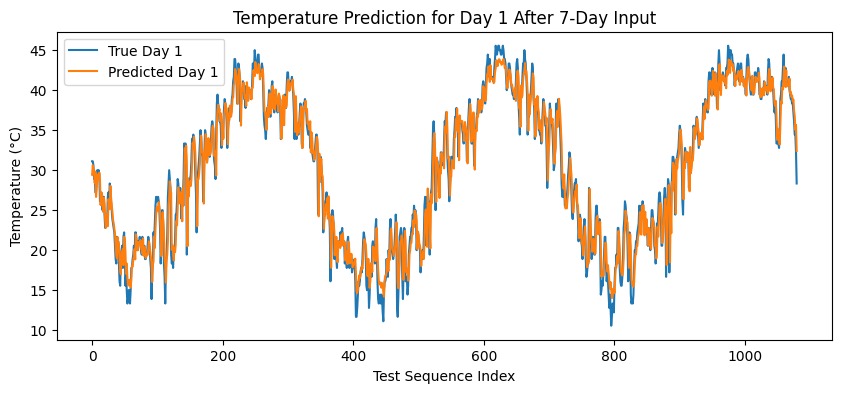

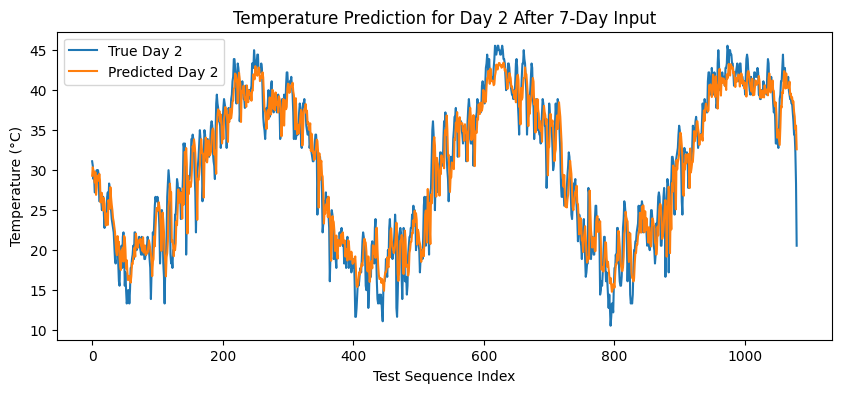

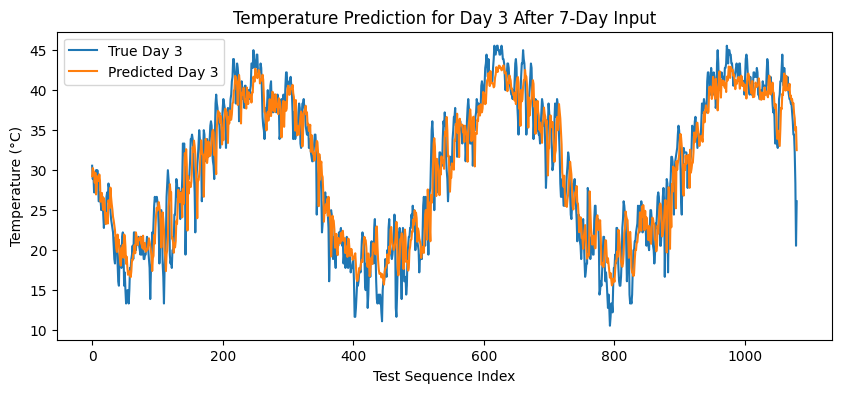

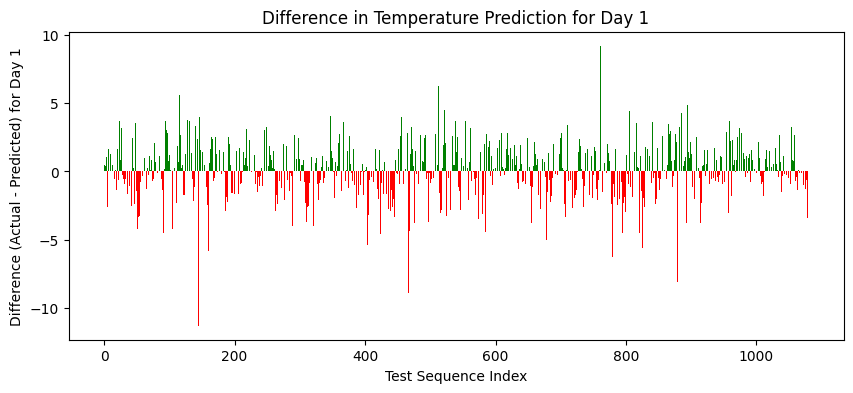

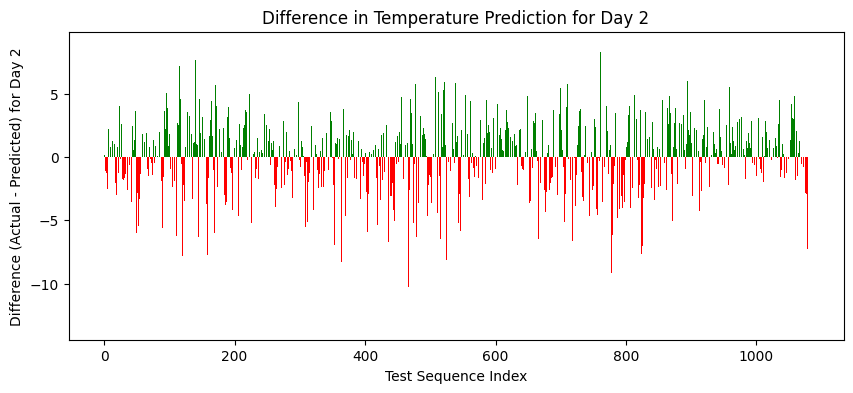

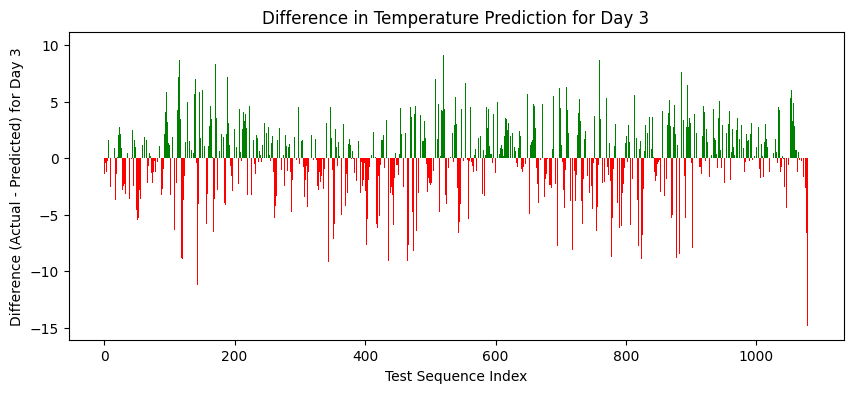


Metrics for Day 1 Prediction:
R² Score: 0.9506
Mean Squared Error (MSE): 4.1309
Mean Absolute Error (MAE): 1.5142
Root Mean Squared Error (RMSE): 2.0325

Metrics for Day 2 Prediction:
R² Score: 0.8980
Mean Squared Error (MSE): 8.5375
Mean Absolute Error (MAE): 2.2657
Root Mean Squared Error (RMSE): 2.9219

Metrics for Day 3 Prediction:
R² Score: 0.8608
Mean Squared Error (MSE): 11.6513
Mean Absolute Error (MAE): 2.6657
Root Mean Squared Error (RMSE): 3.4134


In [16]:
# Apply inverse scaling
y_test_original_7_3 = scaler.inverse_transform(y_test_7_3.reshape(-1, 1)).reshape(len(y_test_7_3), 3)
y_pred_original_3_days = scaler.inverse_transform(y_pred_3_days.reshape(-1, 1)).reshape(len(y_pred_3_days), 3)

print(f"y_test_original_7_3 len: {len(y_test_original_7_3)}")
print(f"y_pred_original_3_days len: {len(y_pred_original_3_days)}")

# Plot actual vs predicted for each day
for day in range(3):
    plt.figure(figsize=(10, 4))
    plt.plot(y_test_original_7_3[:, day], label=f'True Day {day+1}')
    plt.plot(y_pred_original_3_days[:, day], label=f'Predicted Day {day+1}')
    plt.xlabel('Test Sequence Index')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Temperature Prediction for Day {day+1} After 7-Day Input')
    plt.legend()
    plt.show()

# Calculate differences and plot
diff_3_days = y_test_original_7_3 - y_pred_original_3_days
for day in range(3):
    plt.figure(figsize=(10, 4))
    colors = np.where(diff_3_days[:, day] >= 0, 'green', 'red')
    for i in range(len(diff_3_days)):
        plt.bar(i, diff_3_days[i, day], color=colors[i])
    plt.xlabel('Test Sequence Index')
    plt.ylabel(f'Difference (Actual - Predicted) for Day {day+1}')
    plt.title(f'Difference in Temperature Prediction for Day {day+1}')
    plt.show()

# Calculate metrics for each day
for day in range(3):
    r2 = r2_score(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    mse = mean_squared_error(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    mae = mean_absolute_error(y_test_original_7_3[:, day], y_pred_original_3_days[:, day])
    rmse = np.sqrt(mse)
    print(f"\nMetrics for Day {day+1} Prediction:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

In [17]:
# Function to calculate total number of parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Example: Assuming `model` is your PyTorch model
num_parameters = count_parameters(zzfeatuermapQLSTM)

print(f"The model has {num_parameters} trainable parameters.")

The model has 169 trainable parameters.
